# n-rare

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import csv
import os
pd.set_option("display.max_colwidth", None)

In [2]:
raref = "../results/n_rare/gpt_labelled_n_rare_4lemmas_subset.csv"
rare = pd.read_csv(raref, sep=",")
rare["verb_compound"] = rare["verb_compound"].fillna("")

In [3]:
rare

,id,sentence_id,head_id,head_loc,verb,verb_compound,morph_case,lemma,form,sentence,...,level,unique_lemmas,ann_unique_lemmas,not_ann_unique_lemmas,olulisus,my_tag,other_tags,annotated,not_annotated,verb_case_count
0,0,957330,1524751,4,sõitma,täis,in,tipp,tipus,"Tallinnas Kopli poolsaare tipus sõitis neljapäeva hommikul madalikule diislikütust täis väike tanker , mille keret kontrollinud tuukrid ei leidnud laeval suuremaid vigastusi ega kütuseleket .",...,-,1.0,1.0,2.0,-,1.0,0.0,1.0,4.0,5.0
1,1,12994631,20791012,1,populariseerima,,ad,Inglismaa,Inglismaal,Inglismaal populariseeris jõulupuud alles kuninganna Victoria abikaasa prints Albert .,...,-,3.0,3.0,4.0,-,3.0,0.0,3.0,6.0,9.0
2,2,156428,260528,9,kõmama,,el,kinnitus,kinnitusest,"20 aastat hiljem kõmas kogu maailm Todor Zhivkovi kinnitusest , et NSV Liidul ja Bulgaarial võiksid olla ühised kopsud ja ühine vereringe .",...,-,1.0,1.0,6.0,-,1.0,0.0,1.0,7.0,8.0
3,6,8398051,13459274,13,jõudma,edasi,adit,tootmine,tootmisse,"Rahaasutused reageerivad kriisides ja langustes alati esimesena , siis jõuab see edasi tootmisse ja lõpuks tööjõuturule .",...,-,2.0,1.0,9.0,-,1.0,1.0,2.0,9.0,11.0
4,8,17353197,26632104,3,tembeldama,,in,artikkel,artiklis,( Ühes artiklis tembeldas Triin Saagimi pesuvargaks . ) « Eks see ole selline ajakiri ka .,...,-,4.0,4.0,12.0,-,4.0,0.0,4.0,13.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65181,100742,3256148,5232626,11,vajuma,kokku,all,põrand,põrandale,"Mees tõstis ta ruttu mänguautost välja , ta vajus aga põrandale kokku , proovisime veel mitu korda , kuid ta ei suutnud käia ega seista , oli täiesti loid , "" ütles väikese Sanna ema Mari Mehtälä .",...,-,2.0,2.0,8.0,-,5.0,0.0,5.0,10.0,15.0
65182,100746,375878,583597,12,abistama,,adit,Tallinn,Tallinna,"Kuna ei ole ette näha , et ka riik mõnes küsimuses Tallinna abistaks , siis lähiaastatel ei ole kiirtrammi ehitamine Tallinnale jõukohane .",...,-,3.0,2.0,4.0,-,2.0,1.0,3.0,4.0,7.0
65183,100748,11487081,18400010,6,külmuma,,abl,tänav,tänavalt,"Tallinna südalinnast leiti eile hommikul tänavalt külmunud naine , kes suri hiljem Tallinna keskhaiglas .",...,-,1.0,1.0,5.0,-,1.0,0.0,1.0,13.0,14.0
65184,100749,3508348,5649502,30,pöörama,välja,el,aken,aknast,""" Olen Ameerikas olnud monster of omniscience , kuid nüüd on mu mälu juba näost läinud , "" lausub üksteist aastat pärast sajandivahetust sündinud teadlane ning pöörab oma naeratuse aknast välja Vana-Posti tänava peale .",...,-,2.0,1.0,9.0,-,1.0,1.0,2.0,12.0,14.0


In [4]:
# kui palju on iga käände jaoks näiteid
rare["morph_case"].value_counts()

morph_case
ad      12785
el      11824
in      11651
all      9880
adit     7364
abl      6783
ill      4899
Name: count, dtype: int64

In [5]:
# kui palju lemmasid on lõksul
aggreg2 = rare.groupby(["verb", "verb_compound", "morph_case"], dropna=False).agg(
        lemmas = ("lemma", lambda x :len(x))
).sort_values('lemmas', ascending=False).reset_index()
aggreg2

,verb,verb_compound,morph_case,lemmas
0,mähkuma,,ill,15
1,maalima,,ill,15
2,langema,tagasi,ill,15
3,sätestama,,ill,15
4,jooksma,sisse,ill,15
...,...,...,...,...
9439,diagnoosima,kokku,in,1
9440,ruleerima,,all,1
9441,viskama,"välja, välja",in,1
9442,asuma,pärast,in,1


In [6]:
# kui palju on alaleütleva käände lõkse
aggreg3 = rare[rare["morph_case"]=="all"].groupby(["verb", "verb_compound", "morph_case"], dropna=False).agg(
        lemmas = ("lemma", lambda x :len(x))
).sort_values('lemmas', ascending=False).reset_index()
aggreg3

,verb,verb_compound,morph_case,lemmas
0,akkama,,all,8
1,ütlema,vastu,all,8
2,abielluma,,all,8
3,abistama,,all,8
4,aeglustama,,all,8
...,...,...,...,...
1458,pääsema,lahti,all,2
1459,suigutama,,all,2
1460,imbuma,sisse,all,2
1461,hädaldama,,all,2


In [7]:
# ilma compoundi arvestamata
aggreg4 = rare[rare["morph_case"]=="all"].groupby(["verb", "morph_case"], dropna=False).agg(
        lemmas = ("lemma", lambda x :len(x))
).sort_values('lemmas', ascending=False).reset_index()
aggreg4

,verb,morph_case,lemmas
0,saama,all,119
1,tulema,all,116
2,tegema,all,101
3,jääma,all,85
4,võtma,all,76
...,...,...,...
976,hädaldama,all,2
977,suigutama,all,2
978,imbuma,all,2
979,doneerima,all,2


In [8]:
# igale verb+case juurde kui palju on compoundiga ja ilma compoundita lemma esinemisi 

counts = (
    rare.groupby(["verb", "verb_compound", "morph_case"])["lemma"]
      .nunique()
      .reset_index(name="lemma_count")
)

# For each verb + case, check whether both
# a compound and a non-compound version exist
has_compound = (
    rare.assign(has_compound=rare["verb_compound"].ne(""))
      .groupby(["verb", "morph_case"])["has_compound"]
      .agg(["any", "all"])
      .reset_index()
)

# More directly: determine presence of each type
presence = (
    rare.assign(
        compound_type=rare["verb_compound"].eq("").map({
            True: "without_compound",
            False: "with_compound"
        })
    )
    .groupby(["verb", "morph_case", "compound_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Keep only verb + case combinations that have BOTH
# a compound and a non-compound variant
presence["has_both"] = (
    (presence.get("with_compound", 0) > 0) &
    (presence.get("without_compound", 0) > 0)
)

# Add lemma counts
result = (
    rare.assign(
        compound_type=rare["verb_compound"].eq("").map({
            True: "without_compound",
            False: "with_compound"
        })
    )
    .groupby(["verb", "morph_case", "compound_type"])["lemma"]
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

result["has_both"] = (
    (result.get("with_compound", 0) > 0) &
    (result.get("without_compound", 0) > 0)
)

In [9]:
result

compound_type,verb,morph_case,with_compound,without_compound,has_both
0,aasima,ad,0,6,False
1,aasima,in,0,7,False
2,abielluma,abl,0,12,False
3,abielluma,all,0,8,False
4,abistama,adit,0,7,False
...,...,...,...,...,...
6729,üürima,el,5,0,False
6730,šokeerima,all,0,5,False
6731,šokeerima,el,0,8,False
6732,šoppama,in,0,4,False


In [10]:
result[result["verb"]=="vilistama"]

compound_type,verb,morph_case,with_compound,without_compound,has_both
6330,vilistama,ad,6,0,False
6331,vilistama,adit,0,5,False
6332,vilistama,all,7,0,False
6333,vilistama,el,0,8,False
6334,vilistama,in,7,0,False


In [11]:
# kõik need, mille on nii comp kui mitte esinemisi
#f1 = result[result["has_both"]==True]
#f1
# all käändes
f1 = result[result["morph_case"]=="all"]
f1

compound_type,verb,morph_case,with_compound,without_compound,has_both
3,abielluma,all,0,8,False
5,abistama,all,0,8,False
11,aeglustama,all,0,8,False
14,aeguma,all,0,8,False
18,aerutama,all,0,4,False
...,...,...,...,...,...
6718,üllatuma,all,0,8,False
6720,ümisema,all,0,7,False
6725,ütlema,all,31,0,False
6727,ütsima,all,0,4,False


In [12]:
# nimekiri all verbidest (ilma compoundita)
", ".join(rare[(rare["morph_case"]=="all")]["verb"].unique())

'maksustama, plaksutama, hääbuma, hulpima, kysima, käratama, varjuma, mühatama, tulema, laekuma, hoovama, saama, lihtsustuma, sööstma, sebima, lohutama, lõikama, pressima, liitma, evima, püsima, puiklema, ärritama, genereerima, keerama, muigama, hämmastama, põimima, kaunistama, liikuma, soristama, tegema, pakkima, sõitma, kallama, looklema, liigitama, meeldima, formuleerima, rääkima, kristalliseeruma, minetama, kuluma, võtma, fokuseeruma, haldama, hõikuma, katsetama, pakkuma, põruma, kärisema, jääma, viskama, laulma, asuma, iitsatama, ammenduma, järgnema, kippuma, oksendama, hoidma, tohtima, andma, mõtestama, petma, pidurduma, ehitama, sadestuma, õnnitlema, olema, kakama, ühmama, akkama, leidma, vabanduma, toksama, juurutama, eristama, nakatama, kinnitama, jooksma, purustama, imema, kiirendama, realiseeruma, aitama, eirama, kukkuma, astuma, tormama, kuritarvitama, laskma, kõrgenema, nõustama, määrduma, vilistama, laadima, suruma, uuristama, inspireerima, sattuma, plaanitsema, loopima, 

**Chatgpt andis suuremale osale verbidele klassid, alaleütleva osas pakkus nii:**

- Kõige tüüpilisemad klassid, mille juures leidub alaleütlev alluv tegija/adressaat, on:
- Suhtlusverbid (rääkima, ütlema, küsima, sosistama, hüüdma jne)
- Sotsiaalse mõju verbid (aitama, õpetama, nõustama, juhendama)
- Andmise ja ülekandmise verbid (andma, kinkima, saatma, viima)
- Psühholoogilise mõju verbid (meeldima, mõjuma, paeluma)
- Heli- ja tähelepanujuhtimise verbid (vilistama järele, hõikama, lehvitama)


- Kommunikatsiooniverbid (Sõnum on suunatud adressaadile.)  
    rääkima kellele  
    ütlema kellele   
    hüüdma kellele  
    hõikama kellele  
    sosistama kellele  
    karjuma kellelegi  
    kisama kellelegi  
    valetama kellelegi  
  
  
- Heli ja signaali verbid
    vilistama kellele järele  
    hõikama kellele  
    hüüdma kellele  
    pasundama kellelegi  
    lehvitama kellelegi  
    
    
Kui eesmärk on leida verbid, mille leksikaalses valentsis on inimesele suunatud allatiivne argument täiesti tavaline, siis kõige kindlam nimekiri on:

meeldima, kuuluma, piisama, mõjuma, küsima, rääkima, ütlema, vastama, helistama, hõikuma, hüüdma, kisama, karjuma, sosistama, valetama, andma, pakkuma, viima, tooma, kinkima, ulatama, saatma, näitama, esitama, loovutama, annetama, aitama, abistama, nõustama, juhendama, õpetama, inspireerima, kannustama, lohutama, rahustama, hirmutama, ärritama, hämmastama, jahmatama, kiitma, õnnitlema, vilistama, lehvitama, saluteerima, noogutama, viitama, paeluma, köitma.

Keeleteaduslikult on need enamasti adressaadi, saaja, kogejа või kasusaaja rolliga alaleütleva laiendiga verbid.

In [13]:
# kui eemdalada harvadest all märgendustest sellised verbid (olenemata compoundist) siis kas väheneb põhiliselt A hulk

comm_verbs = ['meeldima', 'kuuluma', 'piisama', 'mõjuma', 'küsima', 'rääkima', 'ütlema', 'vastama', 
              'helistama', 'hõikuma', 'hüüdma', 'kisama', 'karjuma', 'sosistama', 'valetama', 'andma', 
              'pakkuma', 'viima', 'tooma', 'kinkima', 'ulatama', 'saatma', 'näitama', 'esitama', 
              'loovutama', 'annetama', 'aitama', 'abistama', 'nõustama', 'juhendama', 'õpetama', 
              'inspireerima', 'kannustama', 'lohutama', 'rahustama', 'hirmutama', 'ärritama', 'hämmastama', 
              'jahmatama', 'kiitma', 'õnnitlema', 'vilistama', 'lehvitama', 'saluteerima', 'noogutama', 
              'viitama', 'paeluma', 'köitma', 'käratama', 'mühatama', 'iitsatama', "ühmama", "mölisema",
             'kisendama', 'lõugama', 'nähvama', 'torisema', 'kuulutama', 'kähvama', 'kiitlema', 'porisema',
              'pobisema', 'röökima', 'ytlema', 'lugema', 'väitma', 'kostma', 'hõikama', 'kysima', 'ümisema',
              'kõssama', 'jahuma', 'kinnitama', 'sebima', 'lubama', 'huikama', 'jutustama', 'ütsima',
              'annuma', 'rehmama', 'süstima', 'anuma', 'õmblema', 'selgitama', 'järgnema', 'sisestama',
              'sositama', 'väisama', 'teenima', 'kirjutama', 'varastama', 'välgutama', 'laulma',
              'müksama', 'tegema', 'sündima', 'olema', 'vuristama'
             ]

# järgnema on küsitav, nt järgnema millele, järgnema sündmusele
# tegema ja olema ??
# annuma = andma ?

In [15]:
#rare[(rare["morph_case"]=="all") & (rare["tag2"]=="A") & (rare["verb"]=="tõstma")]

In [111]:
#rare2[(rare2["morph_case"]=="all") & (rare2["tag2"]=="A") & (rare2.lemma.isin(["mina", "sina", "tema"]))]["verb"].unique()

In [112]:
#rare2[(rare2["morph_case"]=="all") & (rare2["tag2"]=="A")]["verb"].unique()

In [16]:
# jätta välja need lõksud, mis on nö suhtluse ja suure tõenäosusega inimesega seotud verbid all puhul

not_all = rare[rare["morph_case"]!="all"]

is_all = rare[rare["morph_case"]=="all"]

is_all_filtered = is_all[~is_all.verb.isin(comm_verbs)]

rare2 = pd.concat([not_all, is_all_filtered])

In [17]:
len(rare)

65186

In [18]:
len(rare2)

63793

In [120]:
#rare2[rare2["verb"]=="vilistama"]

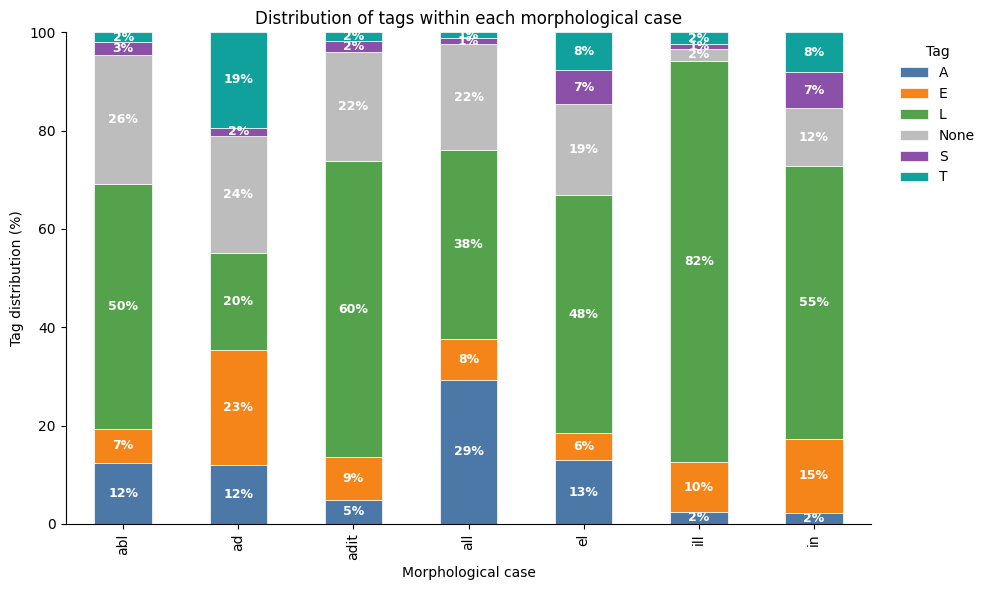

In [19]:

# Copy and make missing values explicit
plot_df = rare2.assign(
    tag=rare2["tag"].fillna("None")
)

# Percentage distribution of tags within each morph_case
pct = (
    pd.crosstab(plot_df["morph_case"], plot_df["tag"], normalize="index")
    .mul(100)
)

# Optional: control the order of tag segments
# pct = pct[["tag1", "tag2", "tag3", "None"]]

ax = pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#4C78A8", "#F58518", "#54A24B", "#BDBDBD", "#8B50A8","#11A19C"],
    edgecolor="white",
    linewidth=0.5
)

ax.set(
    xlabel="Morphological case",
    ylabel="Tag distribution (%)",
    title="Distribution of tags within each morphological case",
    ylim=(0, 100)
)

# Percentage labels
for container in ax.containers:
    labels = [
        f"{v:.0f}%" #if v >= 5 else ""
        for v in pct[container.get_label()]
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

ax.legend(
    title="Tag",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


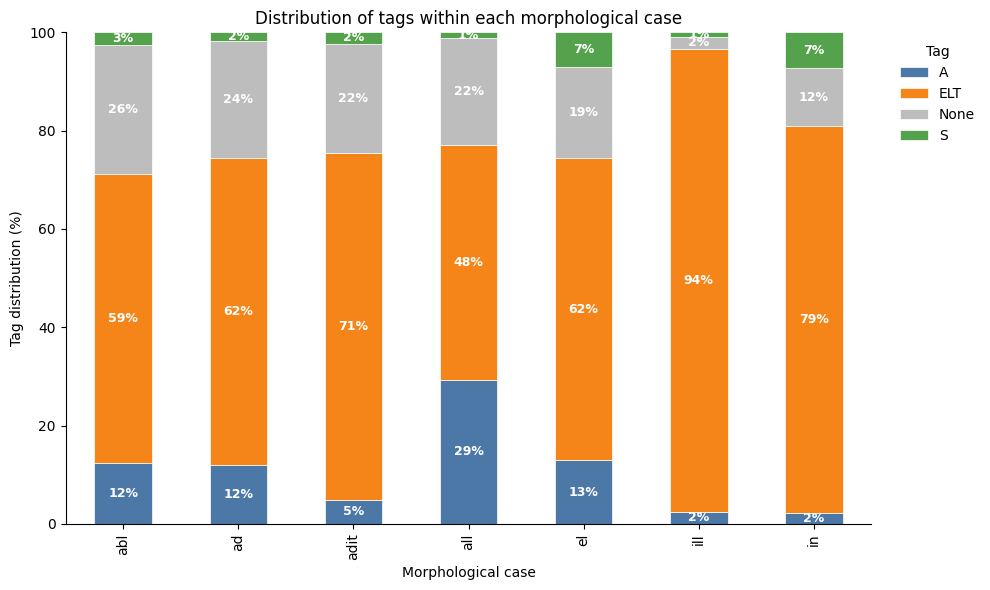

In [20]:
# Copy and make missing values explicit
plot_df = rare2.assign(
    tag2=rare2["tag2"].fillna("None")
)


# Percentage distribution of tags within each morph_case
pct = (
    pd.crosstab(plot_df["morph_case"], plot_df["tag2"], normalize="index")
    .mul(100)
)

# Optional: control the order of tag segments
# pct = pct[["tag1", "tag2", "tag3", "None"]]

ax = pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#4C78A8", "#F58518", "#BDBDBD", "#54A24B" ],
    edgecolor="white",
    linewidth=0.5
)

ax.set(
    xlabel="Morphological case",
    ylabel="Tag distribution (%)",
    title="Distribution of tags within each morphological case",
    ylim=(0, 100)
)

# Percentage labels
for container in ax.containers:
    labels = [
        f"{v:.0f}%" #if v >= 5 else ""
        for v in pct[container.get_label()]
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

ax.legend(
    title="Tag",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


In [21]:
rare2[(rare2["morph_case"]=="all") & (rare2["tag2"]=="A")].sample(20)

,id,sentence_id,head_id,head_loc,verb,verb_compound,morph_case,lemma,form,sentence,...,level,unique_lemmas,ann_unique_lemmas,not_ann_unique_lemmas,olulisus,my_tag,other_tags,annotated,not_annotated,verb_case_count
17990,27929,11546289,18489749,11,viskama,alla,all,helk,Helgile,Naabriproua sõnul viskas Malle laulatusele eelneval päeval võtme aknast alla Helgile .,...,-,3.0,1.0,7.0,-,1.0,2.0,3.0,7.0,10.0
37467,58102,2402351,3850877,28,raugema,,all,kes,kellele,"Seda kanti on etendus külastanud juba viiel erineval aastal , Riverdance'st on saanud omamoodi *veitsi jõulutraditsioon , kuid ka seal ei olnud publik ovatsioonidega kitsi , kellele see stepptantsuparaad meeltmööda , selle vaimustus aastatega ei rauge .",...,-,3.0,2.0,4.0,-,2.0,1.0,3.0,4.0,7.0
1168,1853,7361495,11814525,11,võrsuma,,all,inimkond,inimkonnale,""" Ja pole ju võimatu , et sellest uurimusest kunagi inimkonnale tõelist kasu võrsub .",...,-,1.0,NaN,9.0,-,0.0,1.0,1.0,9.0,10.0
48925,75712,12356458,19783253,4,viljelema,,all,muusik,muusikutele,"Vastupidiselt paljudele väliseesti muusikutele , kes kipuvad esitama peamiselt lorilaule ja on kõikvõimalike süldipidude kangelased , viljelevad Megapopi mehed aktuaalsemat muusikat , mis kisub kuhugi nn . briti rock/popi rajamaile .",...,-,2.0,1.0,5.0,-,1.0,1.0,2.0,5.0,7.0
28876,44811,13085690,20938734,5,mängitama,,all,joodik,joodikutele,Siinseis pubides ei mängita joodikutele « tapeediks » ja ka meie mõistes kontserdiks ei saa niisugust muusikategemist pidada .,...,-,2.0,NaN,11.0,-,0.0,3.0,3.0,15.0,18.0
29325,45489,3340493,5372616,5,tellima,vastu,all,ise,endale,"Eriti šefid mehed tellivad endale kaluripaadi ehk lappaja Munalaidu vastu ja sõidavad praamiajast hoolimata nii , kuis ise tahavad .",...,-,2.0,1.0,2.0,-,1.0,1.0,2.0,5.0,7.0
59362,91729,6431024,10339119,19,särama,vastu,all,suusataja,suusatajatele,"Kurikuulus Tehvandi tõus , kuhu mulluse MK-etapi aegu ilmakapriiside tõttu lund ei jätkunud , säras nüüd täies hiilguses suusatajatele vastu .",...,-,3.0,NaN,3.0,-,0.0,3.0,3.0,9.0,12.0
50548,78183,3046007,4886595,12,lööma,kinni,all,linnajuht,linnajuhtidele,"Peabki olema , selleks ma need piletid välja mõtlesingi ja Tallinna linnajuhtidele pähe kinni lõin !",...,-,1.0,NaN,6.0,-,0.0,1.0,1.0,11.0,12.0
62132,96020,14954877,23468642,11,põrutama,"tagant, sisse",all,eessõitja,eessõitjale,Kuuendal ringil ei jõudnud lihtsalt hoogu maha võtta ning põrutasin eessõitjale tagant sisse .,...,-,2.0,NaN,3.0,-,0.0,2.0,2.0,5.0,7.0
43617,67615,2886763,4628577,9,aimuma,,all,eestlane,eestlastele,"Muide , ühest kuulsaimast tema projekteeritud majast aimub eestlastele Viru hotell .",...,-,3.0,NaN,3.0,-,0.0,3.0,3.0,5.0,8.0


In [22]:
rare2[(rare2["morph_case"]=="all") & (rare2["tag2"]=="A") & (rare2["verb"]=="tõstma")]

,id,sentence_id,head_id,head_loc,verb,verb_compound,morph_case,lemma,form,sentence,...,level,unique_lemmas,ann_unique_lemmas,not_ann_unique_lemmas,olulisus,my_tag,other_tags,annotated,not_annotated,verb_case_count
6252,9705,16552661,25527491,14,tõstma,peale,all,mina,mulle,"Pidin olema telliskividega kaetud kasti sees , mille Ivo Uukkivi ja Tarvo Krall mulle peale tõstsid .",...,-,1.0,NaN,6.0,-,0.0,1.0,1.0,7.0,8.0
6269,9729,8229280,13204613,12,tõstma,ette,all,kõik,kõigile,"Me istume ümber laua , pott on laual ja Anu tõstab kõigile ette .",...,-,3.0,NaN,11.0,-,0.0,3.0,3.0,17.0,20.0
20703,32095,10082005,16173734,9,tõstma,ette,all,ametnik,ametnikule,Alli Tammo tõstis oma päevinäinud jalgratta eile välisministeeriumi ametnikule Märt Piiskopile nagu buldooseri Koidula piiripunktis risti teele ette ja küsis : “ Kuidas ma nüüd Petserisse oma majja saan minna ? ”,...,-,3.0,NaN,11.0,-,0.0,3.0,3.0,17.0,20.0
29301,45452,13870134,22116884,11,tõstma,ette,all,Andres,Andresele,Ta on saanud pliidi äärsete toimetustega ühele poole ja tõstab Andresele ette aurava taldriku .,...,-,3.0,NaN,11.0,-,0.0,3.0,3.0,17.0,20.0
36854,57152,19145215,28879794,13,tõstma,üles,all,justiitsminister,justiitsministrile,"Rahvaalgatuse küsimusel ma ei peatunud , sest Tiit Toomsalu tõstis oma küsimusega justiitsministrile üles täpselt needsamad probleemid , mis olid arutlusel ka komisjonis .",...,-,2.0,NaN,8.0,-,0.0,2.0,2.0,8.0,10.0
37402,58007,8826244,14174787,9,tõstma,ette,all,mina,mulle,"Et ma endiselt vaikisin , siis tõstis ta mulle ise portsu ette , valas mahla klaasi ning tõstis "" kolmandast hunnikust "" salatit toidu kõrvale .",...,-,3.0,NaN,11.0,-,0.0,3.0,3.0,17.0,20.0
40897,63441,4496179,7229259,13,tõstma,ette,all,pere,perele,"Kolme lapse ema stereotüüp on ilmselt ülekaaluline koduperenaine , kes kohtlaselt naeratades perele suppi ette tõstab .",...,-,3.0,NaN,11.0,-,0.0,3.0,3.0,17.0,20.0
56348,87073,9819470,15755486,21,tõstma,ette,all,mees,meestele,Soome võrkpalliliigas tänavu absoluutselt parimaks mängijaks hinnatud Avo Keel ( teistele meie võrkpalluritele seni kättesaamatu tulemus ) tõstis maavõistlusmängudes oma meestele palli ette täpselt ja ootamatult .,...,-,3.0,NaN,11.0,-,0.0,3.0,3.0,17.0,20.0
62318,96317,7137511,11478641,4,tõstma,peale,all,Timo,Timole,"Tõstsin mahakukkunud teki Timole peale ning võtsin niisked saunalinad kaenlasse , et need alla kuivama viia .",...,-,1.0,NaN,6.0,-,0.0,1.0,1.0,7.0,8.0
65099,100611,9825179,15764739,24,tõstma,peale,all,tema,neile,"Kõrgel tornis tundus hirmutav mõte , et Andrus ja Tarmo peavad seal olema ka sel ajal , kui kraana 11 tonni kaaluva tornikiivri neile peale tõstab .",...,-,1.0,NaN,6.0,-,0.0,1.0,1.0,7.0,8.0


In [23]:
rare2["morph_case"].value_counts()

morph_case
ad      12785
el      11824
in      11651
all      8487
adit     7364
abl      6783
ill      4899
Name: count, dtype: int64

## Kui võtta ainult need, millel on mingi märgendus olemas

In [24]:
rare3 = rare2[~rare2["tag2"].isna()]

In [25]:
rare3

,id,sentence_id,head_id,head_loc,verb,verb_compound,morph_case,lemma,form,sentence,...,level,unique_lemmas,ann_unique_lemmas,not_ann_unique_lemmas,olulisus,my_tag,other_tags,annotated,not_annotated,verb_case_count
0,0,957330,1524751,4,sõitma,täis,in,tipp,tipus,"Tallinnas Kopli poolsaare tipus sõitis neljapäeva hommikul madalikule diislikütust täis väike tanker , mille keret kontrollinud tuukrid ei leidnud laeval suuremaid vigastusi ega kütuseleket .",...,-,1.0,1.0,2.0,-,1.0,0.0,1.0,4.0,5.0
1,1,12994631,20791012,1,populariseerima,,ad,Inglismaa,Inglismaal,Inglismaal populariseeris jõulupuud alles kuninganna Victoria abikaasa prints Albert .,...,-,3.0,3.0,4.0,-,3.0,0.0,3.0,6.0,9.0
3,6,8398051,13459274,13,jõudma,edasi,adit,tootmine,tootmisse,"Rahaasutused reageerivad kriisides ja langustes alati esimesena , siis jõuab see edasi tootmisse ja lõpuks tööjõuturule .",...,-,2.0,1.0,9.0,-,1.0,1.0,2.0,9.0,11.0
4,8,17353197,26632104,3,tembeldama,,in,artikkel,artiklis,( Ühes artiklis tembeldas Triin Saagimi pesuvargaks . ) « Eks see ole selline ajakiri ka .,...,-,4.0,4.0,12.0,-,4.0,0.0,4.0,13.0,17.0
5,9,45596,78701,8,jupsima,,ad,aeg,ajal,"Eve kurdab , et süda jupsib viimasel ajal , ja toob kuuldavale sügava ohke .",...,-,2.0,1.0,11.0,-,2.0,1.0,3.0,22.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65121,100645,5026178,8067081,14,saama,tänu,all,laul,laulule,Televaatajate lemmikuks sai Annika Purje - küllap osalt tänu just sellelesamale ainsale eestikeelsele laulule .,...,-,3.0,1.0,9.0,-,1.0,2.0,3.0,10.0,13.0
65135,100667,7286133,11707083,12,heitma,maha,all,ase,asemele,"Kui sünnitust abistatakse seisval lehmal ja loom heidab järsku maha kõvale asemele , siis võib tekkida puusaköbru murd .",...,-,2.0,2.0,4.0,-,2.0,0.0,2.0,4.0,6.0
65173,100731,1244257,1978212,7,leidma,üles,all,juhiiste,juhiistmele,"Tuuleklaasi ülaserva peidetud infrapunakaamera leiab üles juhiistmele istunu silmad ning elektroonika seab elektri-ajamitega vastavalt inimese kasvule paika nii istme , rooli , pedaalid kui isegi auto põranda , et juht saaks jalgu mugavalt toetada .",...,-,4.0,NaN,21.0,-,0.0,4.0,4.0,27.0,31.0
65179,100738,10168550,16314406,5,tasandama,,all,maailmameistritroon,maailmameistritroonile,"Mullu tasandas tema teed maailmameistritroonile peamise konkurendi Michael Schumacheri jalavigastus , tänavu ei saa soomlane vastase ebaõnnele loota .",...,-,4.0,3.0,12.0,-,3.0,1.0,4.0,13.0,17.0


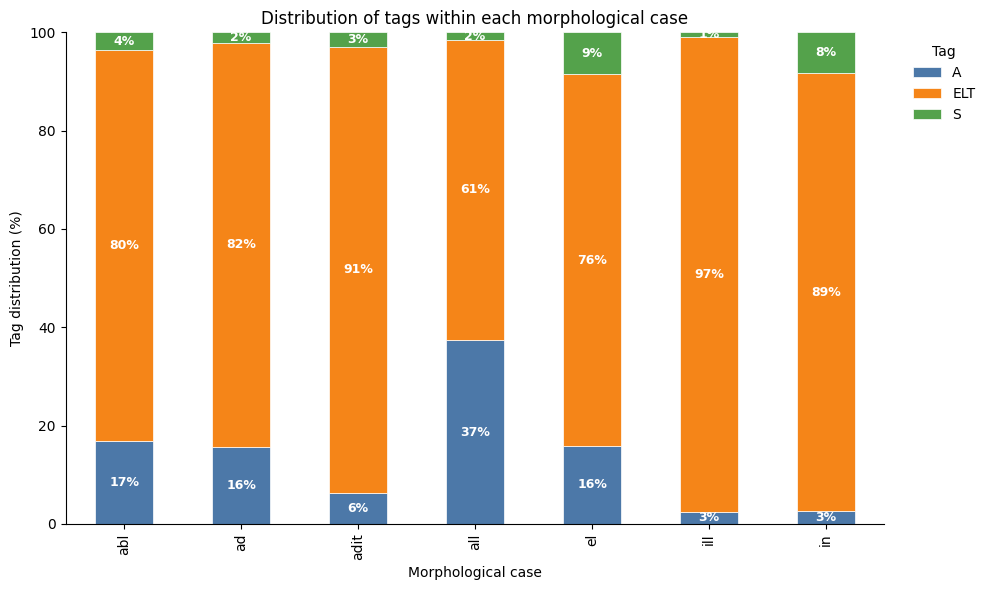

In [26]:
# Copy and make missing values explicit
plot_df = rare3.assign(
    tag2=rare3["tag2"].fillna("None")
)


# Percentage distribution of tags within each morph_case
pct = (
    pd.crosstab(plot_df["morph_case"], plot_df["tag2"], normalize="index")
    .mul(100)
)

# Optional: control the order of tag segments
# pct = pct[["tag1", "tag2", "tag3", "None"]]

ax = pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#4C78A8", "#F58518",  "#54A24B", "#BDBDBD",],
    edgecolor="white",
    linewidth=0.5
)

ax.set(
    xlabel="Morphological case",
    ylabel="Tag distribution (%)",
    title="Distribution of tags within each morphological case",
    ylim=(0, 100)
)

# Percentage labels
for container in ax.containers:
    labels = [
        f"{v:.0f}%" #if v >= 5 else ""
        for v in pct[container.get_label()]
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

ax.legend(
    title="Tag",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
rare3["morph_case"].value_counts()

morph_case
in      10285
ad       9740
el       9630
all      6648
adit     5731
abl      5007
ill      4777
Name: count, dtype: int64